# Optimized Model - XGBoost with Expanded Features

Same goal as `ml_feature_importance.ipynb` but pushing for maximum accuracy. The key differences:
- **XGBoost** instead of Random Forest (tends to perform better on tabular data)
- **More features** including genetics (APOE e4) and medication columns
- **More data** (150k rows instead of 50k)
- **Hyperparameter tuning** via RandomizedSearchCV with cross-validation
- **Readable column names** applied from the rename dictionary

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import shap

%matplotlib inline
np.random.seed(42)

## Column renaming dictionary

Same mapping from `data/rename_columns.ipynb`. Turns the UNREADABLE!! NACC codes into something readable so the SHAP charts and outputs actually make sense at a glance.

In [24]:
column_mapping = {
    'NACCID': 'Patient_ID',
    'VISITYR': 'Visit_Year',
    'NACCAGE': 'Age_At_Visit',
    'SEX': 'Sex_1M_2F',
    'EDUC': 'Years_Education',
    'NACCNE4S': 'APOE4_Allele_Count',
    'NACCUDSD': 'Cognitive_Status',
    'NACCMMSE': 'MMSE_Score',
    'HYPERTEN': 'Hypertension',
    'DIABETES': 'Diabetes',
    'HYPERCHO': 'High_Cholesterol',
    'NACCBMI': 'BMI',
    'CVHATT': 'Heart_Attack',
    'CVAFIB': 'Atrial_Fibrillation',
    'CVANGIO': 'Angioplasty',
    'CVBYPASS': 'Heart_Bypass',
    'CVPACDEF': 'Pacemaker_Defibrillator',
    'CVPACE': 'Pacemaker',
    'CVCHF': 'Congestive_Heart_Failure',
    'CVANGINA': 'Angina',
    'CVOTHR': 'Other_Cardiovascular',
    'DEP': 'Depression',
    'DEPTREAT': 'Depression_Treatment',
    'SLEEPAP': 'Sleep_Apnea',
    'TOBAC30': 'Smoked_Last_30_Days',
    'SMOKYRS': 'Smoking_Years',
    'ALCOHOL': 'Alcohol_Abuse',
    'PD': 'Parkinsons_Disease',
    'PDOTHR': 'Other_Parkinsonism',
    'SEIZURES': 'Seizures',
    'TBI': 'Traumatic_Brain_Injury',
    'TBIOTHR': 'Other_Brain_Trauma',
    'NACCLIPL': 'On_Lipid_Lowering_Med',
    'NACCACEI': 'On_ACE_Inhibitor',
    'NACCADEP': 'On_Antidepressant',
    'NACCDBMD': 'On_Diabetes_Med',
    'NACCAHTN': 'On_Antihypertensive',
    'NACCBETA': 'On_Beta_Blocker',
    'NACCCCBS': 'On_Calcium_Channel_Blocker',
    'NACCDIUR': 'On_Diuretic'
}

## Load data

Loading 150k rows and applying the rename immediately.

In [31]:
file_path = '../data/investigator_nacc72.csv'
print("Loading data...")
try:
    df = pd.read_csv(file_path, low_memory=False)
    df = df.rename(columns=column_mapping)
    print(f"Loaded and renamed: {df.shape}")
except FileNotFoundError:
    print(f"File not found: {file_path}")
    df = pd.DataFrame()

Loading data...
Loaded and renamed: (207454, 1024)


## Prep baseline visits with expanded features

Same baseline only filter as before, but now pulling in genetics, medication columns, and more clinical detail. All using readable names

In [ ]:
if not df.empty:
    df_baseline = df.sort_values(by=['Patient_ID', 'Visit_Year']).drop_duplicates(subset=['Patient_ID'], keep='first')
    print(f"Unique patients: {df_baseline.shape[0]}")

    target = 'Cognitive_Status'

    features = [
        'Age_At_Visit', 'Sex_1M_2F', 'Years_Education',
        'APOE4_Allele_Count',
        'Hypertension', 'Diabetes', 'High_Cholesterol', 'BMI',
        'Heart_Attack', 'Atrial_Fibrillation', 'Angioplasty', 'Heart_Bypass',
        'Pacemaker_Defibrillator', 'Pacemaker', 'Congestive_Heart_Failure', 'Angina', 'Other_Cardiovascular',
        'Depression', 'Depression_Treatment', 'Sleep_Apnea',
        'Smoked_Last_30_Days', 'Smoking_Years', 'Alcohol_Abuse',
        'Parkinsons_Disease', 'Other_Parkinsonism', 'Seizures', 'Traumatic_Brain_Injury', 'Other_Brain_Trauma',
        'On_Lipid_Lowering_Med', 'On_ACE_Inhibitor', 'On_Antidepressant', 'On_Diabetes_Med',
        'On_Antihypertensive', 'On_Beta_Blocker', 'On_Calcium_Channel_Blocker', 'On_Diuretic'
        #'MMSE_Score' # maybe remove it an dcheck how it affects accuracy
    ]

    existing_features = [f for f in features if f in df_baseline.columns]
    print(f"Features found: {len(existing_features)} / {len(features)}")

    if target in df_baseline.columns:
        model_data = df_baseline[existing_features + [target]].copy()
        model_data = model_data[model_data[target].isin([1, 2, 3, 4])]

        # Negative values = missing/unknown in this dataset
        model_data[existing_features] = model_data[existing_features].mask(model_data[existing_features] < 0, np.nan)
        model_data = model_data.fillna(model_data.median())

        print(f"Clean data: {model_data.shape}")
    else:
        print("Target variable Cognitive_Status not found.")

Unique patients: 55268
Features found: 35 / 36
Clean data: (55268, 36)


## Train XGBoost with hyperparameter tuning

RandomizedSearchCV tries 30 different parameter combinations across 5 folds and picks the best one. Takes a few minutes but finds significantly better settings than guessing.

In [33]:
if 'model_data' in locals() and not model_data.empty:
    y = (model_data[target] > 1).astype(int)
    X = model_data[existing_features]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"Class ratio (Normal/Impaired): {scale_ratio:.2f}")

    param_grid = {
        'n_estimators': [200, 400, 600],
        'max_depth': [4, 6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.1, 0.2]
    }

    xgb_base = XGBClassifier(
        scale_pos_weight=scale_ratio,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        xgb_base,
        param_distributions=param_grid,
        n_iter=30,
        scoring='accuracy',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    print("Running hyperparameter search (this may take a few minutes)...")
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    print(f"\nBest params: {search.best_params_}")
    print(f"Best CV accuracy: {search.best_score_:.4f}")

Class ratio (Normal/Impaired): 0.71
Running hyperparameter search (this may take a few minutes)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\blemi\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [13:27:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params: {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV accuracy: 0.6798


## Results on test set

Test Accuracy: 0.6841867197394609

              precision    recall  f1-score   support

      Normal       0.60      0.71      0.65      4573
    Impaired       0.77      0.67      0.71      6481

    accuracy                           0.68     11054
   macro avg       0.68      0.69      0.68     11054
weighted avg       0.70      0.68      0.69     11054



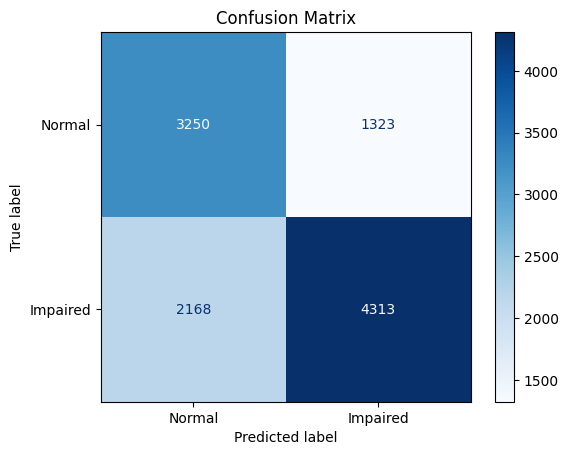

In [34]:
if 'best_model' in locals():
    y_pred = best_model.predict(X_test)

    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Impaired']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Impaired'])
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

## SHAP = what matters most?

Now with readable feature names, the chart is much easier to interpret. Features at the top have the biggest impact on the model's predictions.

C:\Users\blemi\AppData\Local\Temp\ipykernel_27916\2692667859.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample)


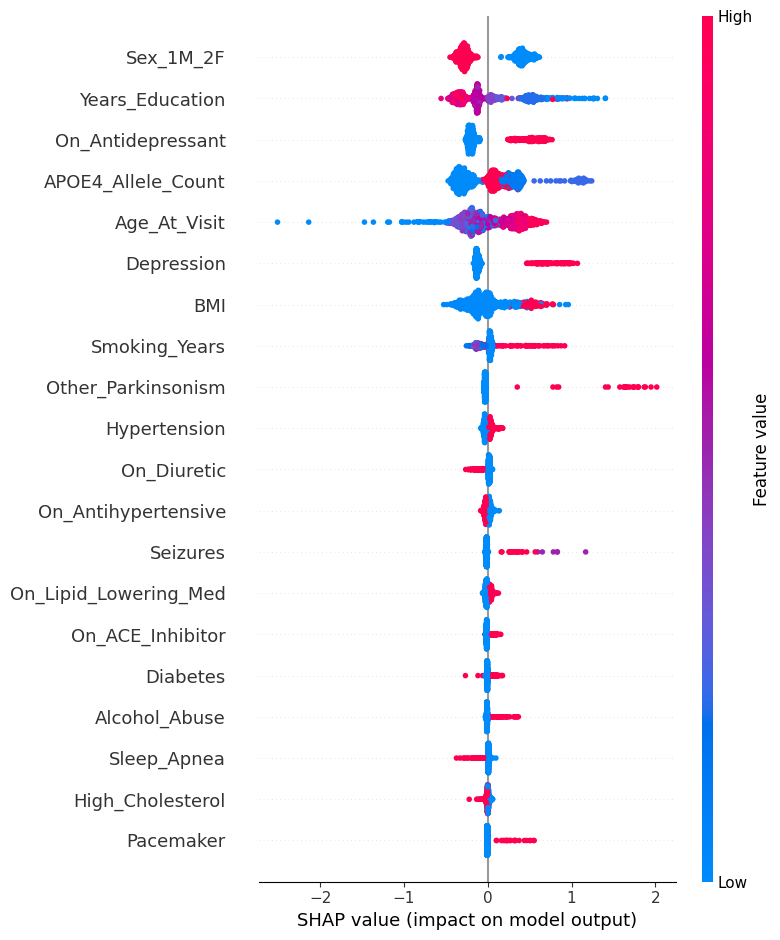

In [35]:
if 'best_model' in locals():
    explainer = shap.TreeExplainer(best_model)

    X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
    shap_values = explainer.shap_values(X_test_sample)

    shap.summary_plot(shap_values, X_test_sample)

## Top 15 features (bar chart)

A cleaner view of just the top features ranked by mean absolute SHAP value.

C:\Users\blemi\AppData\Local\Temp\ipykernel_27916\2232662923.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type='bar', max_display=15)


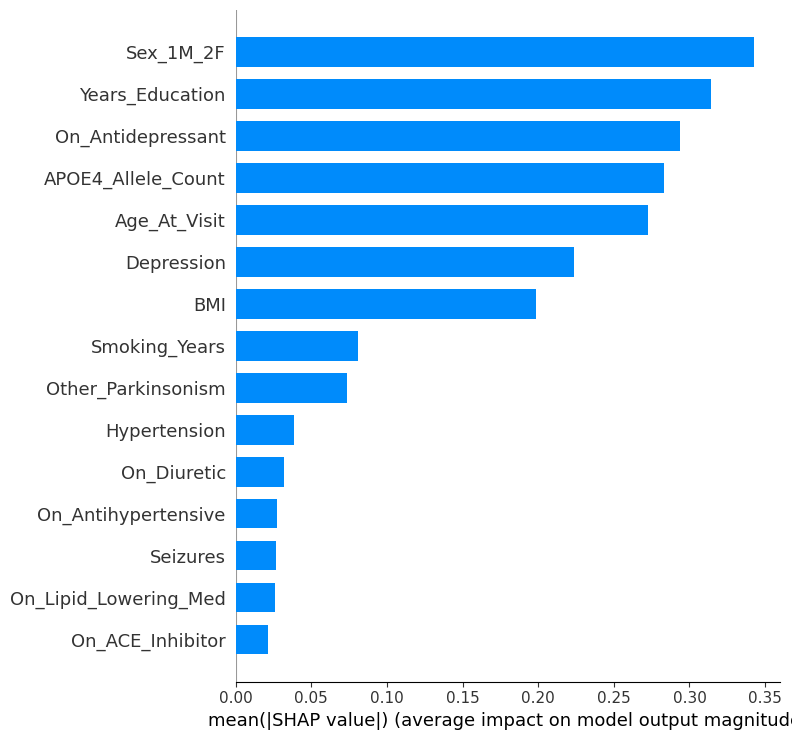

In [36]:
if 'best_model' in locals():
    shap.summary_plot(shap_values, X_test_sample, plot_type='bar', max_display=15)